## Stage 2 - Data Acquisition, Exploration, and Preprocessing

In [1]:
import pandas as pd

df = pd.read_csv('../dontpatronizeme_pcl.tsv', sep='\t', header=None,
                 names=['par_id','art_id','keyword','country','text','label'])

train_ids = pd.read_csv('../train_semeval_parids-labels.csv')
dev_ids   = pd.read_csv('../dev_semeval_parids-labels.csv')

train = df[df['par_id'].isin(train_ids['par_id'])].copy()
dev   = df[df['par_id'].isin(dev_ids['par_id'])].copy()
print(f"Train: {len(train)} rows")
print(f"Dev:   {len(dev)} rows")

Train: 8375 rows
Dev:   2094 rows


In [2]:
# Convert 0-4 labels -> binary 0-1: 0 stays 0, anything >= 1 becomes 1
train['label'] = (train['label'].astype(int) >= 1).astype(int)
dev['label']   = (dev['label'].astype(int) >= 1).astype(int)

print(train['label'].value_counts())

label
0    6825
1    1550
Name: count, dtype: int64


label
0    6825
1    1550
Name: count, dtype: int64
label
0    0.814925
1    0.185075
Name: proportion, dtype: float64


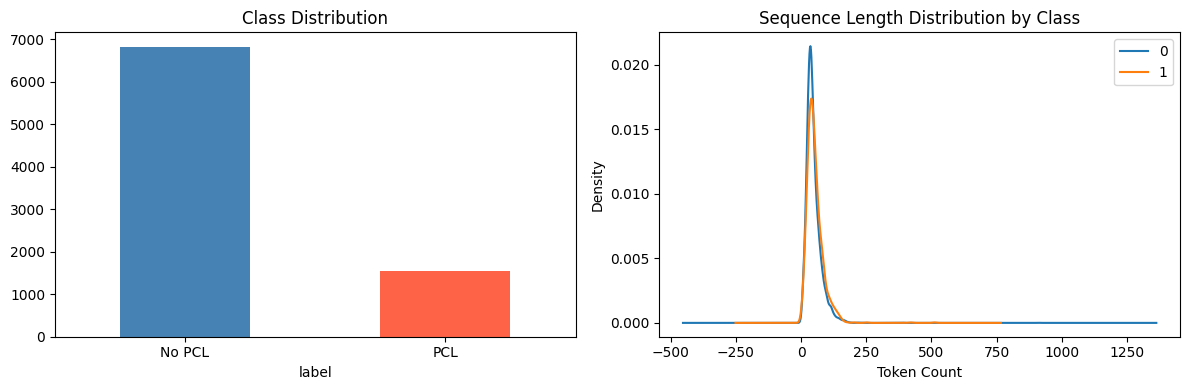

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
print(train['label'].value_counts())
print(train['label'].value_counts(normalize=True))  # imbalance ratio

# Sequence length
train['token_count'] = train['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['No PCL', 'PCL'], rotation=0)

train.groupby('label')['token_count'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Sequence Length Distribution by Class')
axes[1].set_xlabel('Token Count')

plt.tight_layout()
plt.savefig('figures/class_dist_seqlen.pdf', bbox_inches='tight')  # for LaTeX
plt.savefig('figures/class_dist_seqlen.png', bbox_inches='tight', dpi=150)  # for quick viewing

The training corpus comprises 8,375 instances distributed at a 4.4:1 ratio (6,825 No PCL : 1,550 PCL), constituting a pronounced class imbalance that renders raw accuracy an unreliable optimisation target. PCL instances exhibit a marginally elevated mean token count (53.1 vs 47.7), though the distributions overlap substantially (median 46 vs 41), indicating that sequence length alone is insufficient as a discriminative feature. A single No PCL outlier at 909 tokens was identified and warrants inspection for potential noise. These findings motivate two concrete decisions: (1) adoption of a class-weighted cross-entropy loss with weight ratio 4.4:1 to counteract majority-class bias, and (2) a tokeniser max_length of 128, which conservatively accommodates the 75th percentile of both classes (66 and 59 tokens respectively) while remaining computationally tractable.

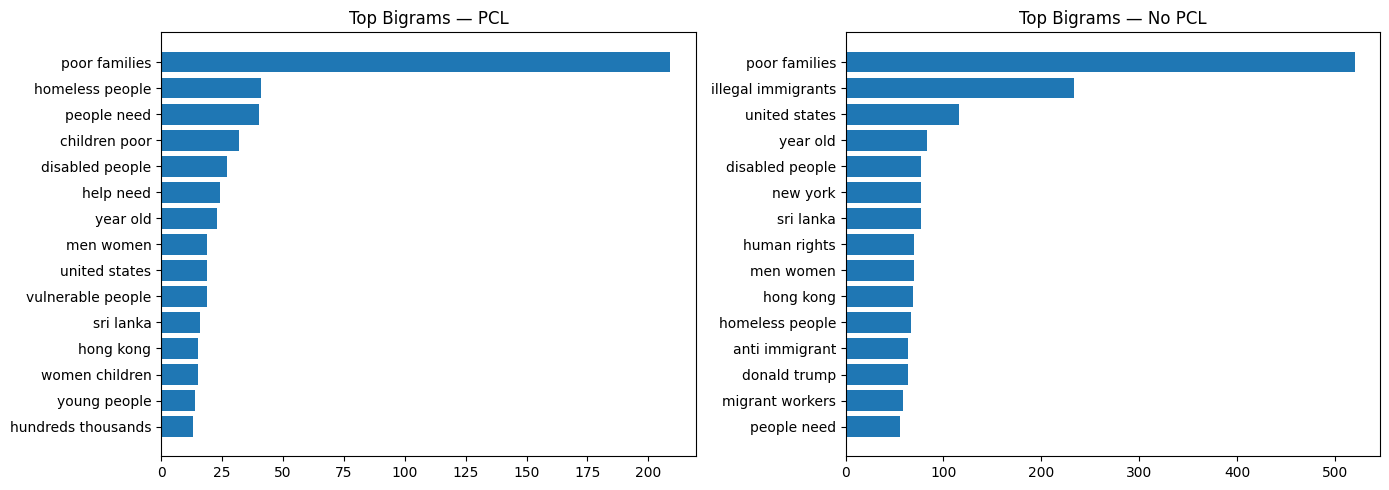

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Top n-grams by class
def top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag = vec.transform(corpus)
    freqs = zip(vec.get_feature_names_out(), np.asarray(bag.sum(axis=0)).ravel())
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:top_k]

pcl_text    = train[train['label']==1]['text']
no_pcl_text = train[train['label']==0]['text']

pcl_bigrams    = top_ngrams(pcl_text,    n=2)
no_pcl_bigrams = top_ngrams(no_pcl_text, n=2)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in zip(axes,
                            [pcl_bigrams, no_pcl_bigrams],
                            ['Top Bigrams — PCL', 'Top Bigrams — No PCL']):
    labels, counts = zip(*data)
    ax.barh(labels, counts)
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/2gram_divergence.pdf', bbox_inches='tight')
plt.savefig('figures/2gram_divergence.png', bbox_inches='tight', dpi=150)

poor families dominate both classes heavily.

Bigram and trigram frequency analysis reveals that surface lexical overlap between classes is substantial — poor families ranks first in both PCL (209 occurrences) and No PCL (520 occurrences), demonstrating that keyword frequency alone is an unreliable discriminative signal. Qualitative inspection of class-distinctive n-grams exposes a more nuanced pattern: PCL trigrams cluster around verb constructions that frame vulnerable groups as passive recipients of benevolent action (help poor families, support poor families), while No PCL trigrams are dominated by named entities and factual references (president donald trump, world war ii). This lexical overlap at the surface level, combined with the structurally distinct framing patterns, provides strong justification for a contextual encoder architecture — specifically a transformer-based model capable of attending to the relational context surrounding high-frequency terms — over a bag-of-words or TF-IDF baseline, which would conflate these overlapping vocabularies.

In [5]:
# check if there are any duplicate texts in training set.
print(f"Duplicate texts: {len(train) - train['text'].nunique()}")

Duplicate texts: 0


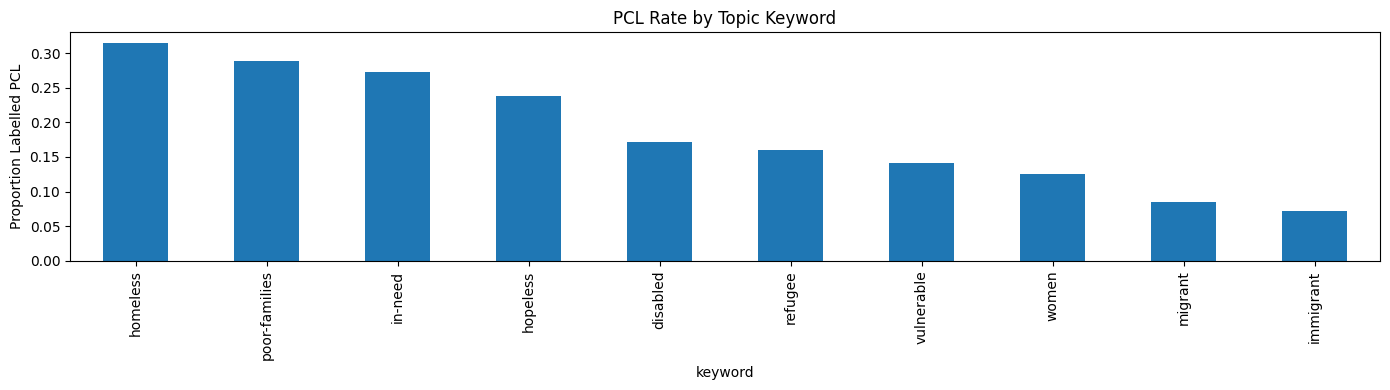

In [6]:
# PCL rate by topic keyword
topic_pcl = train.groupby('keyword')['label'].mean().sort_values(ascending=False)
topic_pcl.plot(kind='bar', figsize=(14, 4), title='PCL Rate by Topic Keyword')
plt.ylabel('Proportion Labelled PCL')
plt.tight_layout()
plt.savefig('figures/pcl_by_topic.pdf', bbox_inches='tight')
plt.savefig('figures/pcl_by_topic.png', bbox_inches='tight', dpi=150)

Topic-stratified analysis reveals substantial variation in PCL prevalence across the ten keyword categories, ranging from 31.5% (homeless) to 7.2% (immigrant) — a 24.3 percentage point spread. Topics centred on immediate, visible economic hardship (homeless, poor-families, in-need) consistently attract higher PCL rates, while politically-framed topics (immigrant, migrant) exhibit markedly lower rates, suggesting that the register of coverage — emotive versus analytical — is a stronger predictor of PCL than the mere presence of a vulnerable group. This topic-level signal has two implications: (1) the model may inherit topic bias if certain keywords are disproportionately represented at inference time, and (2) keyword identity could serve as an auxiliary feature to augment contextual representations, though care must be taken not to overfit to topic as a proxy for PCL given the substantial within-topic variance.

In [7]:
from textblob import TextBlob

train['polarity'] = train['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
train['subjectivity'] = train['text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

print("=== SENTIMENT BY CLASS ===")
print(train.groupby('label')[['polarity', 'subjectivity']].describe().round(4))

=== SENTIMENT BY CLASS ===
      polarity                                                      \
         count    mean     std     min     25%    50%     75%  max   
label                                                                
0       6825.0  0.0180  0.1997 -1.0000 -0.0778  0.000  0.1250  1.0   
1       1550.0  0.0447  0.2054 -0.9167 -0.0596  0.025  0.1662  1.0   

      subjectivity                                                    
             count    mean     std  min     25%     50%     75%  max  
label                                                                 
0           6825.0  0.3819  0.2115  0.0  0.2528  0.4000  0.5000  1.0  
1           1550.0  0.4208  0.2115  0.0  0.3000  0.4352  0.5481  1.0  


- PCL is slightly more positive in polarity (0.045 vs 0.018) — a small but directionally meaningful difference
- PCL is notably more subjective (0.421 vs 0.382) — a 10% relative increase in subjectivity
- Both classes have median polarity of ~0, meaning most text is neutral in tone
- The subjectivity difference is more consistent — the 25th, 50th, and 75th percentiles are all higher for PCL

Sentiment analysis via TextBlob reveals that PCL instances exhibit marginally elevated polarity (0.045 vs 0.018) but more substantially higher subjectivity scores (0.421 vs 0.382), representing a 10.2% relative increase. The near-zero median polarity in both classes confirms that PCL is not characterised by overtly positive or negative affect — a finding that rules out simple sentiment-based classifiers as a viable approach. The subjectivity differential is more diagnostically significant: PCL text is consistently more opinionated in framing across all quartiles, consistent with the passive recipient constructions identified in the n-gram analysis. This corroborates the need for a contextual encoder capable of detecting subtle framing patterns rather than surface-level affective signals.

Why TextBlob is limited here though — it's entirely lexicon-based, meaning it scores word by word with no understanding of context. So it would score these two sentences identically:

"We must help these vulnerable people" (PCL)
"These vulnerable people don't need our help" (Not PCL)

## Preprocessing

Clean html and url

In [8]:
import re
# checking for best max sequence length.
print("=== NOISE ANALYSIS ===")

# Outlier texts
print("Texts under 5 tokens:")
print(train[train['token_count'] < 5][['text', 'label', 'token_count']])

print(f"\nTexts over 128 tokens: {(train['token_count'] > 128).sum()}")

# Special characters -- checking for HTML artifacts, URLs, and newline artifacts, which would pollute text.
train['has_html'] = train['text'].str.contains(r'&amp;|&lt;|&gt;|<[^>]+>', regex=True)
train['has_url']  = train['text'].str.contains(r'http\S+', regex=True)
train['has_newline'] = train['text'].str.contains(r'\\n', regex=True)

print(f"\nHTML artifacts: {train['has_html'].sum()}")
print(f"URLs: {train['has_url'].sum()}")
print(f"Newline artifacts: {train['has_newline'].sum()}")

=== NOISE ANALYSIS ===
Texts under 5 tokens:
                                   text  label  token_count
317              The Filipino immigrant      0            3
1433  Volunteer helps earliest refugees      0            4
1594              UTI in pregnant women      0            4
1656                           refugees      0            1
1954                 Review refugee law      0            3
3120           *Fighting over men/women      0            3
4256    Germans investigate 59 refugees      0            4
4456  Landslide leaves postman homeless      0            4
5131              Focus on the homeless      1            4
6020               Pretty much hopeless      1            3
6738    Repatriation of Afghan refugees      0            4

Texts over 128 tokens: 144

HTML artifacts: 374
URLs: 2
Newline artifacts: 0


In [9]:
print(f"Texts over 128 tokens: {(train['token_count'] > 128).sum()}")
print(f"Percentage truncated at max_length=128: {(train['token_count'] > 128).mean()*100:.2f}%")
print(f"\nTexts over 256 tokens: {(train['token_count'] > 256).sum()}")
print(f"Percentage truncated at max_length=256: {(train['token_count'] > 256).mean()*100:.2f}%")

# Check if truncated texts are disproportionately PCL
print("\n=== LABEL DISTRIBUTION FOR TEXTS OVER 128 TOKENS ===")
long_texts = train[train['token_count'] > 128]
print(long_texts['label'].value_counts())
print(long_texts['label'].value_counts(normalize=True).round(4))

Texts over 128 tokens: 144
Percentage truncated at max_length=128: 1.72%

Texts over 256 tokens: 5
Percentage truncated at max_length=256: 0.06%

=== LABEL DISTRIBUTION FOR TEXTS OVER 128 TOKENS ===
label
0    107
1     37
Name: count, dtype: int64
label
0    0.7431
1    0.2569
Name: proportion, dtype: float64


If use max_length=128, then 37 PCL samples get truncated. For text > 128 tokens, PCL takes 25% but in overall corpus PCL only takes 18%. Thus 128 wouldn't be a good choice to choose as max_length

In [10]:
import html
import re

def clean_text(text):
    text = html.unescape(text)           # fix &amp; &lt; etc.
    text = re.sub(r'<[^>]+>', '', text)  # strip remaining HTML tags like <h>
    text = text.strip()
    return text

train['text'] = train['text'].apply(clean_text)

# verify same rows
print(train[train['has_html']]['text'].head(3))

15    Apart from Pakistan and hosts England , Bangla...
37    Rizvi : There will be no joy this Eid  ' The c...
54    Over the past 15 years , the show has handed o...
Name: text, dtype: str
